# TreasuryCaster: Modelo Preditivo para Taxas de Leilões do Tesouro Nacional

### Estimativa das taxas de leilões do Tesouro Nacional

**Problema preditivo:** Estimar as taxas do título NTN-B do Tesouro Nacional com base em dados históricos e variáveis macroeconômicas. (Variável alvo: TAXA.)

**Por que isso importa:** Títulos do Tesouro Nacional são considerados ativos "livre de risco" no contexto nacional e servem como alicerce em cálculos de custo de oportunidade, bem como de viabilidade para outros investimentos. A capacidade de prever essas taxas pode ajudar na tomada de decisões estratégicas e na gestão de riscos.

**Dataset:** [leiloes_tesouro_nacional.csv](https://www.kaggle.com/datasets/kayoricardo/leiles-da-dvida-pblica-federal-brasil/data) com dados de 2015 a 2023. Combinado com as variáveis macroeconômicas Selic e câmbio do dólar, obtidas via API do Banco Central do Brasil.

In [167]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "src").is_dir() and root != root.parent:
    root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [168]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.dataset import (
    load_raw_data,
    get_selic_sgs,
    get_usd_sgs,
    inspect_data,
    save_data_to_csv,
)
from src.plots import (
    plot_histogram,
    plot_histogram_by_category,
    plot_scatter,
    plot_correlation_heatmap,
    plot_boxplots
)
from src.features import (
    treat_outliers_iqr,
    add_duration_column,
    add_market_rejection_column,
    add_lag_column,
    select_final_columns,
    split_time_series,
    calculate_vif,
    scale_features
)
from src.modeling import train_model, evaluate_model

from src.config import PROCESSED_FILE, FINAL_FILE

## Fase 1: Análise Exploratória de Dados (EDA)

In [169]:
# Carrega o dataset principal de leilões do Tesouro Nacional usando a função `load_raw_data` do módulo `dataset.py`.

df = load_raw_data()

df.head()

,NUMERO_PORTARIA,VENCIMENTO,FINANCEIRO BCB,QUANTIDADE ACEITA,TAXA,TIPO,DATA,FINANCEIRO ACEITO,BENCHMARK,OFERTA,TITULO,QUANTIDADE BCB,LIQUIDACAO,FINANCEIRO ACEITO SEGUNDA VOLTA,QUANTIDADE ACEITA SEGUNDA VOLTA,TIPO_LEILAO,ACEITO/OFERTADO
0,1622,01/10/2024,0.0,1000000,10.2410,Venda,2023-12-21,9.273300e+08,LTN 12 meses,1000000,LTN,0,22/12/2023,0.000000e+00,0.0,Pré,1.000
1,1622,01/10/2025,0.0,12000000,9.7248,Venda,2023-12-21,1.017911e+10,LTN 24 meses,12000000,LTN,0,22/12/2023,0.000000e+00,0.0,Pré,1.000
2,1622,01/07/2027,0.0,7550000,9.9239,Venda,2023-12-21,5.417575e+09,LTN 48 meses,10000000,LTN,0,22/12/2023,0.000000e+00,0.0,Pré,0.755
3,1623,01/01/2029,0.0,1000000,10.1110,Venda,2023-12-21,1.043813e+09,NTN-F 6 anos,1000000,NTN-F,0,22/12/2023,0.000000e+00,0.0,Pré,1.000
4,1623,01/01/2033,0.0,350000,10.4296,Venda,2023-12-21,3.586164e+08,NTN-F 10 anos,500000,NTN-F,0,22/12/2023,1.219738e+08,118996.0,Pré,0.700


In [170]:
# Busca as séries históricas da Selic e do dólar na API do Banco Central, usando as funções `get_selic_sgs` e `get_usd_sgs` do módulo `dataset.py`.

df_selic = get_selic_sgs()
df_usd = get_usd_sgs()

In [171]:
# Verifica os últimos registros das séries históricas da Selic e do Dólar para garantir que os dados foram carregados corretamente.

df_selic.tail(), df_usd.tail()

(           DATA     SELIC
 2250 2023-12-22  0.043739
 2251 2023-12-26  0.043739
 2252 2023-12-27  0.043739
 2253 2023-12-28  0.043739
 2254 2023-12-29  0.043739,
            DATA  USD_VALOR
 2250 2023-12-22     4.8619
 2251 2023-12-26     4.8368
 2252 2023-12-27     4.8306
 2253 2023-12-28     4.8413
 2254 2023-12-29     4.8413)

In [172]:
# Combina os Dataframes de Selic e Dólar com o Dataframe principal (para isso foi preciso transformar a coluna 'DATA' no objeto datetime).

df['DATA'] = pd.to_datetime(df['DATA'], format='%Y-%m-%d')  
df = df.merge(df_selic, on='DATA', how='left')
df = df.merge(df_usd, on='DATA', how='left')

In [173]:
# Inspeção do dataset enriquecido.

inspect_data(df)


=== INSPEÇÃO DO DATASET ===
Shape: (4305, 19)

Colunas: ['NUMERO_PORTARIA', 'VENCIMENTO', 'FINANCEIRO BCB', 'QUANTIDADE ACEITA', 'TAXA', 'TIPO', 'DATA', 'FINANCEIRO ACEITO', 'BENCHMARK', 'OFERTA', 'TITULO', 'QUANTIDADE BCB', 'LIQUIDACAO', 'FINANCEIRO ACEITO SEGUNDA VOLTA', 'QUANTIDADE ACEITA SEGUNDA VOLTA', 'TIPO_LEILAO', 'ACEITO/OFERTADO', 'SELIC', 'USD_VALOR']

Tipos de dados:
NUMERO_PORTARIA                             int64
VENCIMENTO                                    str
FINANCEIRO BCB                            float64
QUANTIDADE ACEITA                           int64
TAXA                                      float64
TIPO                                          str
DATA                               datetime64[us]
FINANCEIRO ACEITO                         float64
BENCHMARK                                     str
OFERTA                                      int64
TITULO                                        str
QUANTIDADE BCB                              int64
LIQUIDACAO       

,NUMERO_PORTARIA,VENCIMENTO,FINANCEIRO BCB,QUANTIDADE ACEITA,TAXA,TIPO,DATA,FINANCEIRO ACEITO,BENCHMARK,OFERTA,TITULO,QUANTIDADE BCB,LIQUIDACAO,FINANCEIRO ACEITO SEGUNDA VOLTA,QUANTIDADE ACEITA SEGUNDA VOLTA,TIPO_LEILAO,ACEITO/OFERTADO,SELIC,USD_VALOR
count,4305.000000,4305,4.305000e+03,4.305000e+03,4305.000000,4305,4305,4.305000e+03,3872,4.305000e+03,4305,4.305000e+03,4305,3.247000e+03,3.247000e+03,4305,4305.000000,4305.000000,4305.000000
unique,NaN,84,NaN,NaN,NaN,3,NaN,NaN,20,NaN,4,NaN,801,NaN,NaN,2,NaN,NaN,NaN
top,NaN,01/01/2029,NaN,NaN,NaN,Venda,NaN,NaN,LTN 48 meses,NaN,LTN,NaN,20/03/2020,NaN,NaN,Pré,NaN,NaN,NaN
freq,NaN,271,NaN,NaN,NaN,3830,NaN,NaN,476,NaN,1421,NaN,32,NaN,NaN,2527,NaN,NaN,NaN
mean,690.022532,NaN,5.622247e+08,1.209318e+06,6.337608,NaN,2019-09-04 23:39:15.679442,1.863560e+09,NaN,1.489389e+06,NaN,4.302049e+05,NaN,2.189125e+08,1.729719e+05,NaN,0.666551,0.033051,4.362750
min,1.000000,NaN,0.000000e+00,0.000000e+00,-0.008000,NaN,2015-01-08 00:00:00,0.000000e+00,NaN,1.000000e+04,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000,0.007469,2.575400
25%,291.000000,NaN,0.000000e+00,5.500000e+04,2.672400,NaN,2017-08-24 00:00:00,1.425477e+08,NaN,3.000000e+05,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.235000,0.019930,3.686900
50%,550.000000,NaN,0.000000e+00,4.448000e+05,6.030000,NaN,2019-12-05 00:00:00,8.984802e+08,NaN,1.000000e+06,NaN,0.000000e+00,NaN,5.880188e+07,2.258600e+04,NaN,1.000000,0.029256,4.181200
75%,882.000000,NaN,0.000000e+00,1.500000e+06,10.275000,NaN,2021-09-30 00:00:00,2.166391e+09,NaN,1.500000e+06,NaN,0.000000e+00,NaN,2.698758e+08,1.674640e+05,NaN,1.000000,0.050788,5.164700
max,10646.000000,NaN,3.001775e+10,3.000000e+07,16.900000,NaN,2023-12-21 00:00:00,6.494205e+10,NaN,3.000000e+07,NaN,3.000000e+07,NaN,6.070685e+09,5.999996e+06,NaN,1.000000,0.052531,5.937200


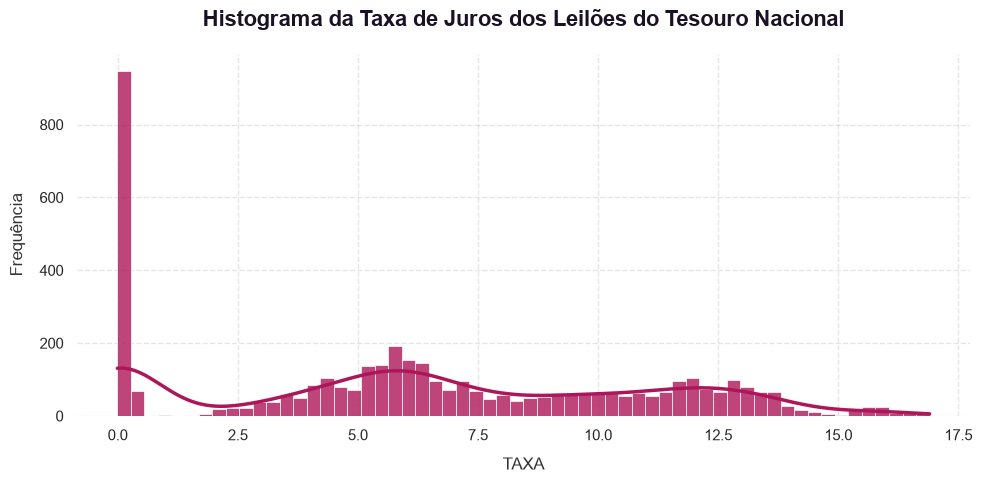

In [174]:
# Histograma da variável de interesse TAXA.

plot_histogram(df, column='TAXA', title='Histograma da Taxa de Juros dos Leilões do Tesouro Nacional', filename='histogram_taxa.png')

O histograma da variável de interesse TAXA reflete uma informação importante sobre o Dataset: a presença de títulos com naturezas bem distintas. As NTN-B, por exemplo, são títulos indexados à inflação, que rendem à pessoa investidora uma taxa nominal acrescida do IPCA, enquanto as NTN-F são títulos totalmente prefixados.

Analisando o gráfico vemos um pico bem à esquerda representando possivelmente: valores zerados na tabela, mas também as taxas associadas aos títulos LFT (Tesouro Selic), que recebem uma taxa modificadora bem pequena em relação à Selic.

O pico no meio, entre 5 e 7 provavelmente indica as taxas da NTN-B, representando o rendimento do título acima da inflação.

Já o pico mais à direita, próximo ao 12,5, representaria as LTN e NTN-F, os títulos prefixados, que rendem apenas a taxa nominal e portanto têm taxas mais altas.

Este é o motivo pelo qual no escopo deste projeto faremos o recorte de análise apenas para as NTN-B.

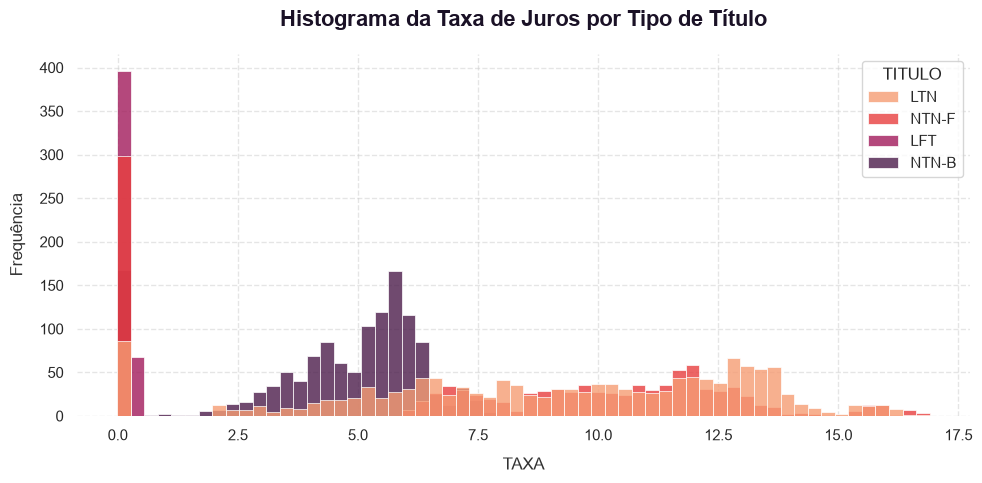

In [175]:
# Histograma da variável de interesse TAXA, segmentado por tipo de título

plot_histogram_by_category(df, column='TAXA', hue='TITULO', title='Histograma da Taxa de Juros por Tipo de Título', filename='histogram_taxa_by_tipo_titulo.png')

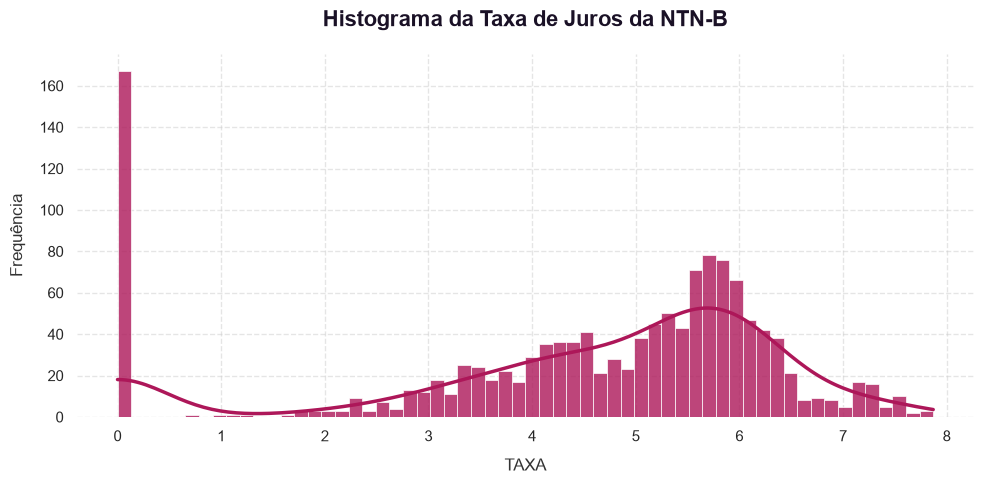

In [176]:
# Histograma da variável de interesse TAXA apenas para os títulos do tipo NTN-B.

df_ntnb = df[df['TITULO'] == 'NTN-B']
plot_histogram(df_ntnb, column='TAXA', title='Histograma da Taxa de Juros da NTN-B', filename='histogram_taxa_ntnb.png')

In [177]:
# Contagem de valores zerados na coluna TAXA do DataFrame filtrado para títulos NTN-B.

(df_ntnb['TAXA'] == 0).sum()

np.int64(167)

O gráfico segmentado por título corrobora a análise anterior, mostrando que as taxas da NTN-B estão mais concentradas entre 5 e 7, enquanto as taxas das LTN e NTN-F estão concentradas acima de 10.

O histograma dos títulos NTN-B mostra que a distribuição das taxas é mais próxima da normal, ainda que com uma cauda à esquerda. O dataset contem 167 registros com taxa igual a zero para as NTN-B, que serão tratados na fase limpeza.

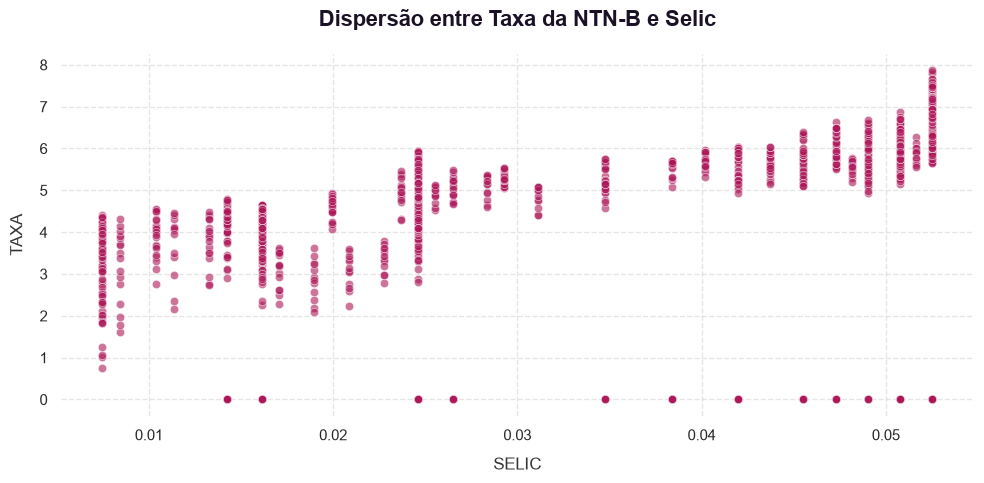

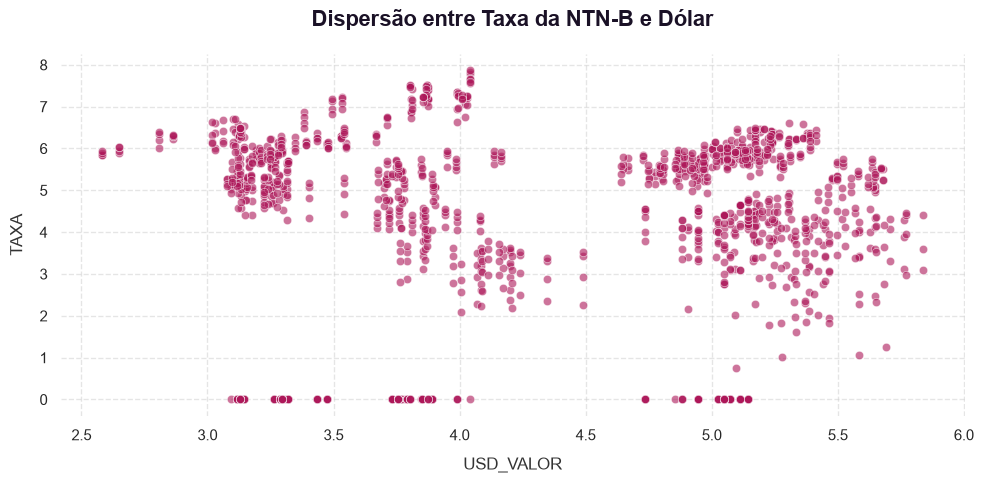

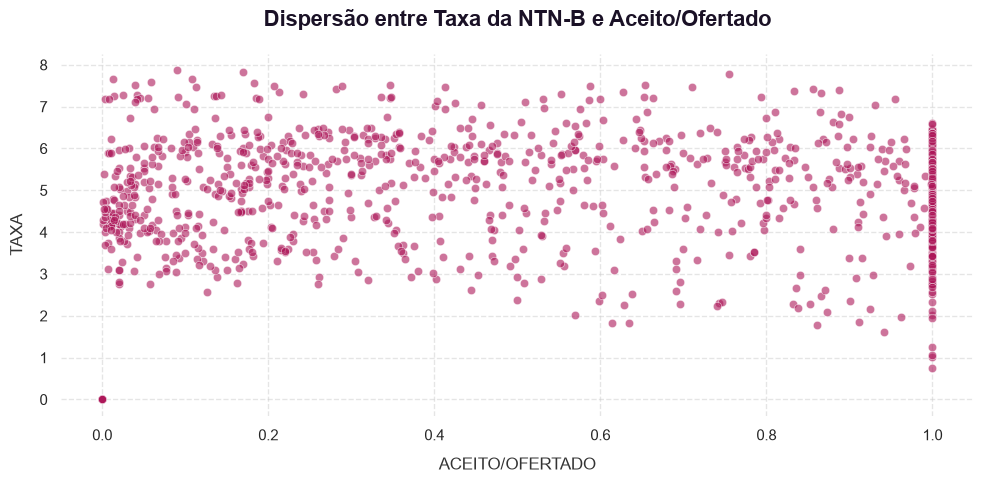

In [178]:
# Gráfico de dispersão entre TAXA e Selic, entre TAXA e Dólar, e entre TAXA e Aceito/Ofertado.

plot_scatter(df_ntnb, x='SELIC', y='TAXA', title='Dispersão entre Taxa da NTN-B e Selic', filename='scatter_taxa_selic.png')
plot_scatter(df_ntnb, x='USD_VALOR', y='TAXA', title='Dispersão entre Taxa da NTN-B e Dólar', filename='scatter_taxa_usd.png')
plot_scatter(df_ntnb, x='ACEITO/OFERTADO', y='TAXA', title='Dispersão entre Taxa da NTN-B e Aceito/Ofertado', filename='scatter_taxa_aceito_ofertado.png')

Notem que a taxa Selic, embora seja uma variável numérica, não se trata de uma variável contínua, mas sim discreta, pois seus valores são definidos pelo Comitê de Política Monetária (Copom) em suas reuniões a cada 45 dias e costumam variar em saltos de 0,25% ou 0,50%.

A coluna Aceito/Ofertado representa a relação entre a quantidade de títulos efetivamente vendida (aceita) e a quantidade inicialmente oferecida em leilão pelo Tesouro Nacional. Trago esta variável como uma métrica do apetite do mercado e das condições de financiamento do governo: o valor 1.0 indica que 100% dos títulos ofertados foram absorvidos pelo mercado, enquanto valores menores que 1.0 indicam que parte do lote foi rejeitada — seja por falta de demanda ou porque o Tesouro não aceitou pagar as taxas exigidas pelos investidores.

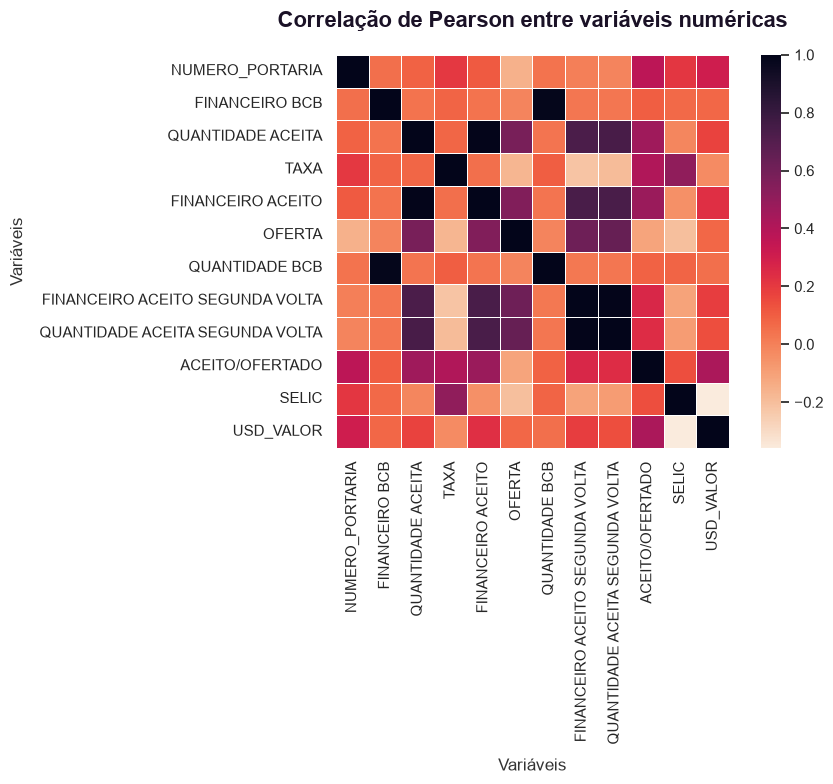

In [179]:
# Mapa de calor de correlação de Pearson.

plot_correlation_heatmap(df_ntnb, title='Correlação de Pearson entre variáveis numéricas', filename='correlation_heatmap.png')

No universo das NTN-B, a nossa variável de interesse TAXA tem correlação de 0,41 com a variável Aceito/Ofertado, reforçando a ideia de que a demanda do mercado tem alguma relação com a taxa de juros do título.

A correlação com a Selic é de 0,51, enquanto a correlação com o dólar é de -0,03. Retornarei a esses valores depois de realizar a limpeza e pré-processamento dos dados, mas por enquanto parece que o câmbio não tem relação com a taxa de juros do título.

A Selic, por sua vez, é a taxa básica de juros da economia. Se a Selic sobe, o rendimento dos títulos pós-fixados aumenta, o que força as NTN-B (que pagam IPCA acrescida de juros reais) a aumentarem suas taxas para continuarem atrativas para os investidores. Essa relação de mercado pode trazer ao mesmo tempo uma oportunidade de previsão, mas também um risco de multicolinearidade, que será avaliado mais adiante.

## Fase 2: Limpeza e tratamento de dados

In [180]:
# Calcula linhas duplicadas no DataFrame filtrado para títulos NTN-B.

duplicated_rows = df_ntnb.duplicated()
print(f"Número de linhas duplicadas: {duplicated_rows.sum()}")

Número de linhas duplicadas: 0


In [181]:
# Identifica valores ausentes (NaN) nas colunas de interesse:

df_ntnb_missing = df_ntnb[['TAXA', 'SELIC', 'USD_VALOR', 'ACEITO/OFERTADO', 'DATA', 'VENCIMENTO']].isnull().sum()

print("Valores ausentes por coluna:")
print(df_ntnb_missing)

Valores ausentes por coluna:
TAXA               0
SELIC              0
USD_VALOR          0
ACEITO/OFERTADO    0
DATA               0
VENCIMENTO         0
dtype: int64


In [182]:
# Verifica a presença de valores zero nas colunas de interesse.

df_ntnb_zero_values = df_ntnb[['TAXA', 'SELIC', 'USD_VALOR', 'ACEITO/OFERTADO']].eq(0).sum()
print("Valores zero por coluna:")
print(df_ntnb_zero_values)  

Valores zero por coluna:
TAXA               167
SELIC                0
USD_VALOR            0
ACEITO/OFERTADO    167
dtype: int64


In [183]:
# Filtra as linhas onde ambas as colunas (TAXA e ACEITO/OFERTADO) são iguais a zero, para confirmar se são as mesmas.

same_zeros = df_ntnb[(df_ntnb['TAXA'] == 0) & (df_ntnb['ACEITO/OFERTADO'] == 0)]

print(f"Quantidade de linhas onde ambas as colunas são zero: {len(same_zeros)}")

Quantidade de linhas onde ambas as colunas são zero: 167


In [184]:
# Remove registros onde o valor da TAXA é zero.

df_clean = df_ntnb[df_ntnb['TAXA'] != 0]

In [185]:
# Calcula quantidade de operações de compra e de venda no Dataset.

df_clean['TIPO'].value_counts()

TIPO
Venda     1070
Compra      77
Name: count, dtype: int64

In [186]:
# Mantem no Dataframe apenas as operações de venda, removendo as operações de compra.

df_clean = df_clean[df_clean['TIPO'] == 'Venda']

In [187]:
# Converte a coluna 'VENCIMENTO' para o tipo datetime, caso ainda não esteja nesse formato.

df_clean['VENCIMENTO'] = pd.to_datetime(df_clean['VENCIMENTO'], format='%d/%m/%Y')

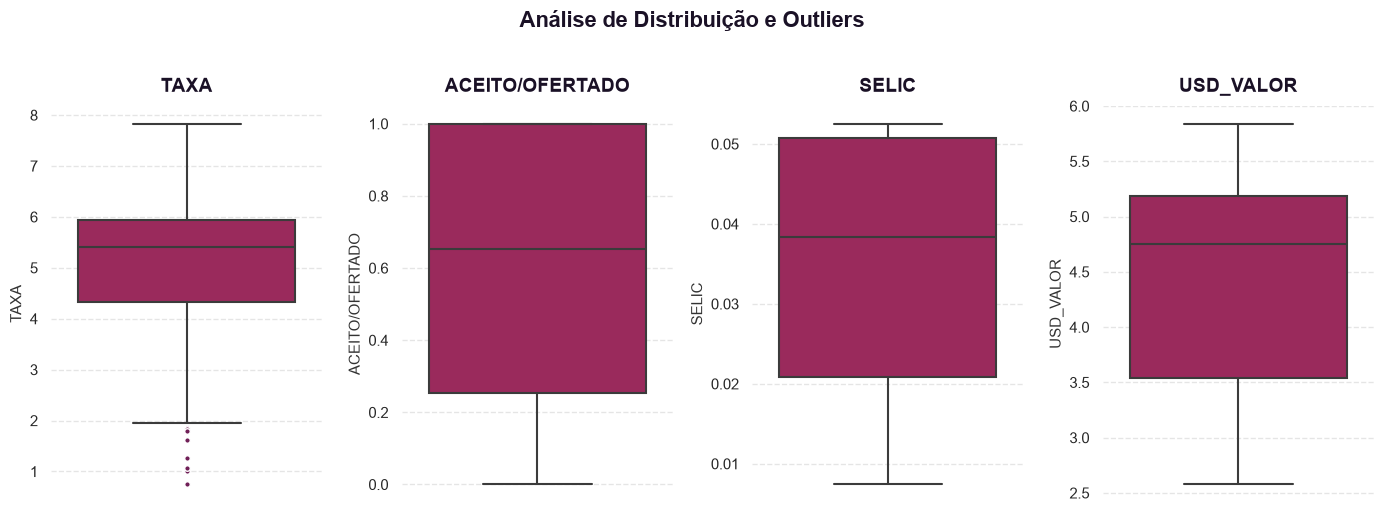

In [188]:
# Plota boxplot para as colunas de interesse, para análise de distribuição e identificação de outliers.

colunas_analise = ['TAXA', 'ACEITO/OFERTADO', 'SELIC', 'USD_VALOR']

plot_boxplots(
    df=df_clean, 
    cols=colunas_analise, 
    title="Análise de Distribuição e Outliers", 
    filename="boxplots_distribuicao_features.png"
)

In [189]:
# Identifica e limita outliers na coluna 'TAXA' usando o método do IQR (Interquartile Range).

df_clean_v2 = treat_outliers_iqr(df_clean, columns=['TAXA'], factor=1.5, method='limit')

Coluna 'TAXA': Encontrados 9 outliers (limite_inferior=1.91, limite_superior=8.34)


In [190]:
# Identifica e limita outliers na coluna ACEITO/OFERTADO.

df_clean_v2 = treat_outliers_iqr(df_clean_v2, columns=['ACEITO/OFERTADO'], factor=1.5, method='limit')

Coluna 'ACEITO/OFERTADO': Encontrados 0 outliers (limite_inferior=-0.87, limite_superior=2.12)


**Discussão**

- Nesta etapa foi constatado que não haviam registros duplicados ou nulos nas colunas de interesse.

- Foram identificados 167 registros com taxa igual a zero, que representam leilões rejeitados ou cancelados (o que foi confirmado pelo valor também zerado na coluna ACEITO/OFERTADO). Para que esses valores não sejam confundidos com uma taxa de juros real, enviesando o modelo, esses registros foram removidos do dataset.

**Importante:** Ao remover os registros com taxa zero, introduzimos no dataset um viés de sobrevivência, pois consideramos apenas os leilões que foram bem-sucedidos. Sendo assim, consideramos que o modelo gerado no presente projeto é um modelo condicional: ele prevê a taxa visto que o leilão foi aceito pelo mercado. Em futuros projetos, esse problema pode ser resolvido com dois modelos em esteira: primeiro um modelo de classificação para prever se o leilão será aceito ou rejeitado, e depois um modelo de regressão para prever a taxa do leilão aceito.

- Foram removidas as operações do tipo 'Compra' (77 registros, a essa altura da limpeza), por representarem leilões de recompra/resgate antecipado, cuja dinâmica de precificação é diferente da lógica de financiamento público estudada nesta modelagem.

- A coluna DATA já havia sido convertida para o tipo datetime previamente para servir de integração com as séries temporais de Selic e Dólar. Na presente etapa, a coluna VENCIMENTO foi também convertida para o tipo datetime, para permitir a análise de maturidade dos títulos que será preparada na fase de feature engineering.

- Foi utilizado o método IQR (Interquartile Range) para identificar e tratar outliers na coluna TAXA. O método calcula os limites inferior e superior com base no primeiro e terceiro quartis multiplicados por um fator. O método IQR identificou apenas 9 registros como outliers, que foram limitados aos valores de limites mais próximos (Winsorização).

- Não foram identificados outliers na coluna ACEITO/OFERTADO.

- Apesar de ter plotado o boxplot da taxa Selic e do câmbio, caso houvesse valores extremos, essas cifras seriam entendidas aqui como fatos econômicos reais e históricos, que precisam ser mantidos para que o modelo aprenda as relações entre a taxa e Selic/dólar. Felizmente, a ausência de outliers permite o uso da regressão linear como algoritmo de modelagem, por este ser sensível a outliers.

- O Dataframe das NTN-B tinha 1.314 registros e depois da limpeza ficou com 1.070 registros.

- Veremos como fica a distribuição da taxa de juros da NTN-B após a limpeza e tratamento de outliers abaixo:

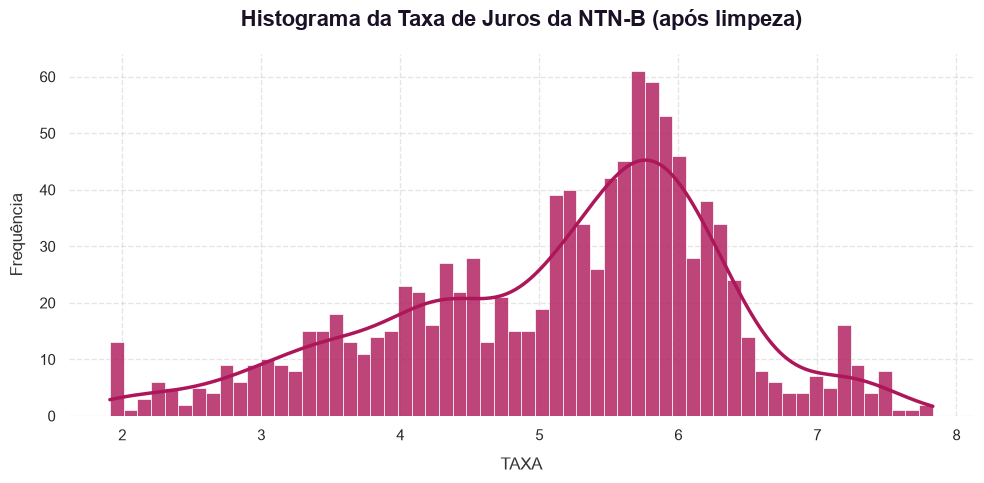

In [191]:
# Plota histograma da coluna 'TAXA' após a limpeza e tratamento de outliers.

plot_histogram(df_clean_v2, column='TAXA', title='Histograma da Taxa de Juros da NTN-B (após limpeza)', filename='histogram_taxa_cleaned.png')

In [192]:
# Consulta a correlação de Pearson entre TAXA e SELIC, e entre TAXA e USD_VALOR no dataframe limpo e tratado de outliers (df_clean_v2).

corr_selic = df_clean_v2['SELIC'].corr(df_clean_v2['TAXA'])
corr_usd = df_clean_v2['USD_VALOR'].corr(df_clean_v2['TAXA'])
print(f"Correlação de Pearson entre SELIC e TAXA: {corr_selic:.4f}")
print(f"Correlação de Pearson entre USD e TAXA: {corr_usd:.4f}")

Correlação de Pearson entre SELIC e TAXA: 0.8571
Correlação de Pearson entre USD e TAXA: -0.2848


- A limpeza e tratamento de outliers levou a correlação entre a SELIC e a variável de interesse TAXA de 0,51 para 0,86. A análise de multicolinearidade dirá se essa variável será mantida no modelo.
- A correlação entre a variável de interesse TAXA e a variável USD_VALOR passou de -0,03 para -0,28, o que já a retira do mero ruído. Mesmo que seja uma correlação fraca, será mantida nas etapas seguintes de modelagem.

## Fase 3: Feature Engineering

In [193]:
# Adiciona novas colunas ao DataFrame.

df_engineered = (
    df_clean_v2
    .pipe(add_duration_column, date='DATA', maturity_date='VENCIMENTO')
    .pipe(add_market_rejection_column, accepted_column='ACEITO/OFERTADO', threshold=0.15)
    .pipe(add_lag_column, date='DATA', target_column='TAXA')
)

print(df_engineered[['DATA', 'TAXA', 'DURACAO', 'TAXA_ULTIMO_LEILAO', 'REJEICAO_MERCADO']].head())

        DATA    TAXA  DURACAO  TAXA_ULTIMO_LEILAO  REJEICAO_MERCADO
0 2015-01-27  5.8400     1569              5.8897                 0
1 2015-01-27  5.8999     7413              6.0300                 1
2 2015-01-27  5.9300    14718              6.0400                 0
3 2015-01-27  5.8500     3030              5.9300                 0
4 2015-02-10  6.3400     7399              5.8999                 0


**Discussão**

Foram adicionadas três novas colunas ao dataset:

- DURACAO: representa a duração em dias entre a data do leilão e a data de vencimento do título. Essa variável é importante para o modelo, pois títulos com vencimentos mais longos tendem a ter taxas mais altas, refletindo o risco de inflação e de mercado ao longo do tempo.
- REJEICAO_MERCADO: sinaliza o comportamento de rejeição do mercado. É uma variável binária (dummy) que assume o valor 1 se a proporção ACEITO/OFERTADO for menor que 15%. A introdução dessa feature permite que a Regressão Linear capture o impacto desproporcional (não-linear) que episódios de severa frustração de demanda exercem sobre a taxa do título, algo que a variável ACEITO/OFERTADO sozinha pode não conseguir explicar.
- TAXA_ULTIMO_LEILAO: representa a taxa do leilão anterior do título. Essa variável visa capturar a memória do mercado e a tendência das taxas ao longo do tempo, permitindo que o modelo reconheça padrões históricos de precificação. Em função da ausência de dados anteriores ao primeiro leilão de cada título (levando em conta os vencimentos diferentes), os primeiros registros de cada vencimento teriam valor nulo nessa coluna. Para que o modelo possa ser treinado, esse registro foi removido do dataset na função que adiciona esta feature.


In [194]:
save_data_to_csv(df_engineered, PROCESSED_FILE)

Dataset salvo com sucesso em: /Users/felipequerette/PythonProjects/brazilian-treasury-rate-prediction/data/processed/leiloes_tesouro_nacional_processed.csv


## Fase 4: Preparação do dataset para modelagem

In [195]:
# Conjunto de variáveis que serão utilizadas na modelagem preditiva.

explanatory = [ 'SELIC', 'USD_VALOR', 'ACEITO/OFERTADO', 'DURACAO', 'TAXA_ULTIMO_LEILAO', 'REJEICAO_MERCADO' ]

X = df_engineered[explanatory].copy()
Y = df_engineered['TAXA'].copy()

X_train, X_test, y_train, y_test = split_time_series(X, Y)

print(f"Treino: {X_train.shape}   Teste: {X_test.shape}")

Treino: (841, 6)   Teste: (210, 6)


In [196]:
# Análise de multicolinearidade entre as variáveis explicativas usando o VIF (Variance Inflation Factor).

df_vif = calculate_vif(X_train)
print(df_vif)

SELIC                 4.783350
TAXA_ULTIMO_LEILAO    4.018731
ACEITO/OFERTADO       2.444057
USD_VALOR             2.139662
REJEICAO_MERCADO      1.912159
DURACAO               1.116464
Name: VIF, dtype: float64


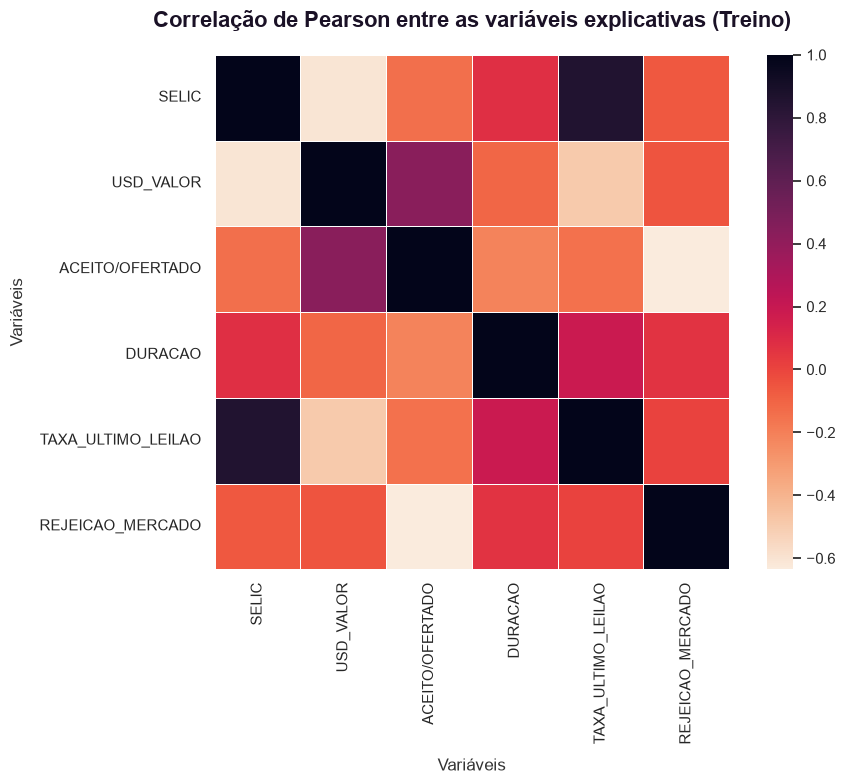

In [197]:
# Plota o mapa de calor da correlação de Pearson entre as variáveis explicativas no conjunto de treino.

plot_correlation_heatmap(X_train, title='Correlação de Pearson entre as variáveis explicativas (Treino)', filename='correlation_heatmap_explanatory_train.png')

**Discussão**

- Neste etapa foram mantidas apenas as colunas utilizadas na modelagem preditiva, que são: SELIC, USD_VALOR, ACEITO/OFERTADO, DURACAO, TAXA_ULTIMO_LEILAO e REJEICAO_MERCADO. Lembrando que a variável alvo é a TAXA.

- Não foi aplicada a codificação nas variáveis categóricas deste dataset. A variável de rejeição do mercado já foi criada como uma variável binária.

- A divisão entre treino e teste foi feita com 80% dos dados para treino e 20% para teste. Essa divisão foi feita de forma cronológica, para que o modelo seja treinado com dados históricos e testado com dados mais recentes, simulando a situação real de previsão. O uso de amostragem aleatória em dados temporais teria gerado uma falha metodológica de vazamento de dados, onde informações do futuro são misturadas ao conjunto de treino para prever o passado. Esse risco se torna ainda mais crítico devido à inclusão da variável TAXA_ULTIMO_LEILAO, que carrega explicitamente a memória do evento imediatamente anterior.

- Foi feito o cálculo do VIF (Variance Inflation Factor) para avaliar a multicolinearidade entre as variáveis explicativas. Considerando que valores de VIF acima de 5 ou 10 indicam multicolinearidade significativa, os resultados deste cálculo foram um grande alívio! Com base no resultado do cálculo de VIF, nenhuma variável foi removida do modelo.

| Variável | VIF |
| :--- | ---: |
| SELIC | 4.306771 |
| TAXA_ULTIMO_LEILAO | 4.223192 |
| ACEITO/OFERTADO | 2.848945 |
| REJEICAO_MERCADO | 1.948565 |
| USD_VALOR | 1.779394 |
| DURACAO | 1.177170 |



In [198]:
# Salva o dataframe final usado na modelagem: apenas as variáveis explicativas e variável alvo, antes da padronização.

df_final = select_final_columns(df_engineered, explanatory, "TAXA")
save_data_to_csv(df_final, FINAL_FILE)

Dataset salvo com sucesso em: /Users/felipequerette/PythonProjects/brazilian-treasury-rate-prediction/data/final/leiloes_tesouro_nacional_final.csv


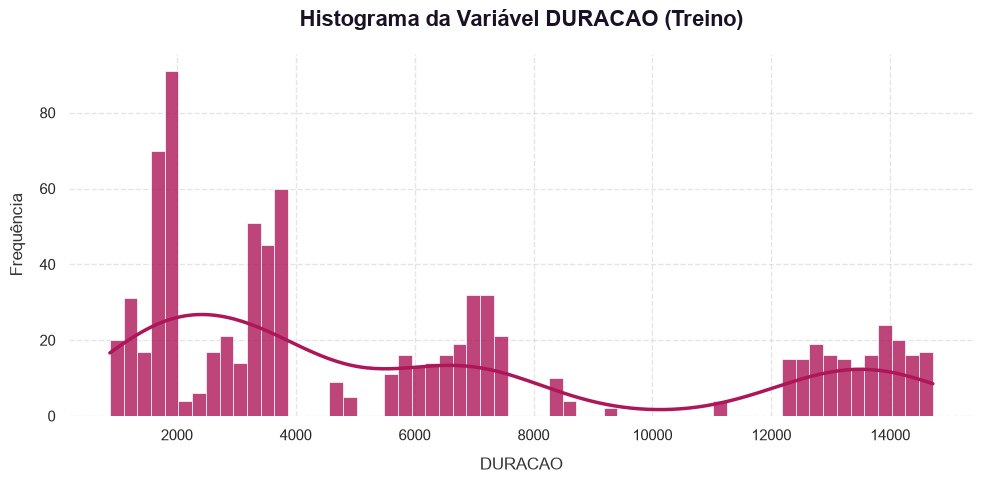

Média: 5968.94, Mediana: 3775.00, Desvio Padrão: 4486.66


In [199]:
# Analisa a distribuição da variável DURACAO antes de aplicar a padronização, para entender a escala e a dispersão dos dados.

plot_histogram(X_train, column='DURACAO', title='Histograma da Variável DURACAO (Treino)', filename='histogram_duracao_train.png')

print(f"Média: {X_train['DURACAO'].mean():.2f}, Mediana: {X_train['DURACAO'].median():.2f}, Desvio Padrão: {X_train['DURACAO'].std():.2f}")


In [200]:
# Padronização das variáveis explicativas.

columns_to_scale = ['TAXA_ULTIMO_LEILAO', 'USD_VALOR', 'SELIC', 'DURACAO']
X_train_scaled, X_test_scaled = scale_features(
    X_train, 
    X_test, 
    columns=columns_to_scale
)

**Padronização**

Por envolver prazos longos calculados em dias, foi feita uma verificação da distribuição da variável DURACAO antes de aplicar a padronização. Apesar da distribuição ser assimétrica — devido à existência de alguns títulos com vencimentos muito longos — a média (4.075) e a mediana (3.444) são proporcionalmente próximas e o desvio padrão é de 2.716 dias. Assim, não foi necessário aplicar uma transformação logarítmica antes da padronização.

Foi feita a padronização das variáveis explicativas SELIC, USD_VALOR, DURACAO e TAXA_ULTIMO_LEILAO. As colunas ACEITO/OFERTADO e REJEICAO_MERCADO não foram modificadas; a primeira porque já é uma proporção naturalmente contida entre 0 e 1, e a segunda por se tratar de uma variável binária. Para isso foi utilizado o método ColumnTransformer dentro da função scale_features, que aplica a padronização apenas nas colunas especificadas, mantendo as demais colunas intactas.

## Fase 5: Modelagem, Validação e Diagnóstico de Overfitting

In [201]:
# Treino no modelo de regressão linear, previsão e avaliação do desempenho do modelo nos dados de treino e teste.

model = train_model(X_train_scaled, y_train)

y_train_prediction = model.predict(X_train_scaled)
y_test_prediction = model.predict(X_test_scaled)

metrics_train = evaluate_model(model, X_train_scaled, y_train)
metrics_test = evaluate_model(model, X_test_scaled, y_test)

print("Regressão Linear - TREINO")
for metric_name, metric_value in metrics_train.items():
    print(f"  {metric_name}: {metric_value:,.4f}")

print("\nRegressão Linear - TESTE")
for metric_name, metric_value in metrics_test.items():
    print(f"  {metric_name}: {metric_value:,.4f}")


Regressão Linear - TREINO
  MAE: 0.1962
  MSE: 0.0888
  RMSE: 0.2980
  R2: 0.9442

Regressão Linear - TESTE
  MAE: 0.2568
  MSE: 0.0942
  RMSE: 0.3069
  R2: 0.2268


**Discussão**

Nos dados de teste, de acordo com a métrica MAE, o modelo erra em média 0,20 pontos percentuais na previsão da taxa do leilão. Ou seja, se a taxa do leilão for 6,00%, o modelo prevê entre 5,80% e 6,20%. A métrica R2 indica que o modelo explica 92% da variação da taxa do leilão, o que é um resultado excessivamente bom para um modelo de regressão linear simples.

O dado estranho de um resultado melhor nos dados de teste do que nos dados de treino pode ser explicado pelo fato de que o modelo foi treinado com dados anteriores de uma janela de tempo mais longa, que podem ter apresentado maior volatilidade e incerteza econômica, enquanto os dados de teste são mais recentes e podem estar refletindo uma janela temporal mais estável.

Mas há uma outra interpretação necessária, uma variável do passado recente que tem uma correlação avassaladora com o presente, como veremos a seguir:

In [202]:
# Extrai os coeficientes do modelo, pareia com o nome das colunas e calcula o valor absoluto.

importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})

importance_df['Absolute_Importance'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False)

print("Influência das Variáveis (Coeficientes Padronizados):")
print(importance_df[['Feature', 'Coefficient']].to_string(index=False))

Influência das Variáveis (Coeficientes Padronizados):
           Feature  Coefficient
TAXA_ULTIMO_LEILAO     1.072051
             SELIC     0.217529
         USD_VALOR     0.089730
   ACEITO/OFERTADO    -0.057752
           DURACAO     0.023582
  REJEICAO_MERCADO     0.020145


O que vemos aqui é que o modelo está praticamente copiando a variável TAXA_ULTIMO_LEILAO, que é a taxa do leilão anterior do mesmo título. De fato, o que parece ser o caso é que o melhor preditor para a taxa de juros de amanhã é, esmagadoramente, a taxa de juros de hoje.

Por outro lado, perdemos a oportunidade de encontrar a relação entre a taxa do leilão e outras variáveis macroeconômicas, que é o objetivo principal deste projeto. 

In [203]:
# Recupera o dataframe final sem a variável de lag TAXA_ULTIMO_LEILAO, para treinar um modelo sem essa variável.

df_final_sans_lag = df_final.drop(columns=['TAXA_ULTIMO_LEILAO'])

explanatory_sans_lag = [ 'SELIC', 'USD_VALOR', 'ACEITO/OFERTADO', 'DURACAO', 'REJEICAO_MERCADO' ]

X = df_final_sans_lag[explanatory_sans_lag].copy()
Y = df_final_sans_lag['TAXA'].copy()

X_train, X_test, y_train, y_test = split_time_series(X, Y)

print(f"Treino: {X_train.shape} Teste: {X_test.shape}")

columns_to_scale_sans_lag = ['USD_VALOR', 'SELIC', 'DURACAO']
X_train_scaled, X_test_scaled = scale_features(
    X_train, 
    X_test, 
    columns=columns_to_scale_sans_lag
)


Treino: (841, 5) Teste: (210, 5)


In [204]:
# Novo treinamento sem a variável de lag TAXA_ULTIMO_LEILAO.

model = train_model(X_train_scaled, y_train)

y_train_prediction = model.predict(X_train_scaled)
y_test_prediction = model.predict(X_test_scaled)

metrics_train = evaluate_model(model, X_train_scaled, y_train)
metrics_test = evaluate_model(model, X_test_scaled, y_test)

print("Regressão Linear - TREINO")
for metric_name, metric_value in metrics_train.items():
    print(f"  {metric_name}: {metric_value:,.4f}")

print("\nRegressão Linear - TESTE")
for metric_name, metric_value in metrics_test.items():
    print(f"  {metric_name}: {metric_value:,.4f}")

Regressão Linear - TREINO
  MAE: 0.5000
  MSE: 0.3748
  RMSE: 0.6122
  R2: 0.7644

Regressão Linear - TESTE
  MAE: 0.6309
  MSE: 0.4978
  RMSE: 0.7056
  R2: -3.0858


In [205]:
# Extrai os coeficientes do modelo, pareia com o nome das colunas e calcula o valor absoluto.

importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})

importance_df['Absolute_Importance'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False)

print("Influência das Variáveis (Coeficientes Padronizados):")
print(importance_df[['Feature', 'Coefficient']].to_string(index=False))

Influência das Variáveis (Coeficientes Padronizados):
         Feature  Coefficient
           SELIC     1.165946
REJEICAO_MERCADO     0.211899
         DURACAO     0.156027
       USD_VALOR     0.144655
 ACEITO/OFERTADO     0.015945


A SELIC atua como o piso gravitacional da taxa, mas fatores microestruturais do leilão (como a rejeição dos dealers) e temporais (duração) também são responsáveis por calibrar o prêmio de risco final pago pelo Estado.